
Predicted percentages (first 20 patients):
 Patient  Diagnosis(1-Anxiety, 0-No Anxiety)  Logistic Regression (%)  Random Forest (%)  XGBoost (%)
 1       1                                   79.35                     78.96             73.27       
 2       0                                    0.30                      1.16              0.62       
 3       0                                    0.30                      4.07              0.57       
 4       0                                    5.62                     13.09              9.71       
 5       0                                    0.00                      0.18              0.00       
 6       0                                   58.51                     65.57             63.97       
 7       0                                   21.99                     28.99             28.32       
 8       0                                   17.32                     18.73             15.44       
 9       0                            

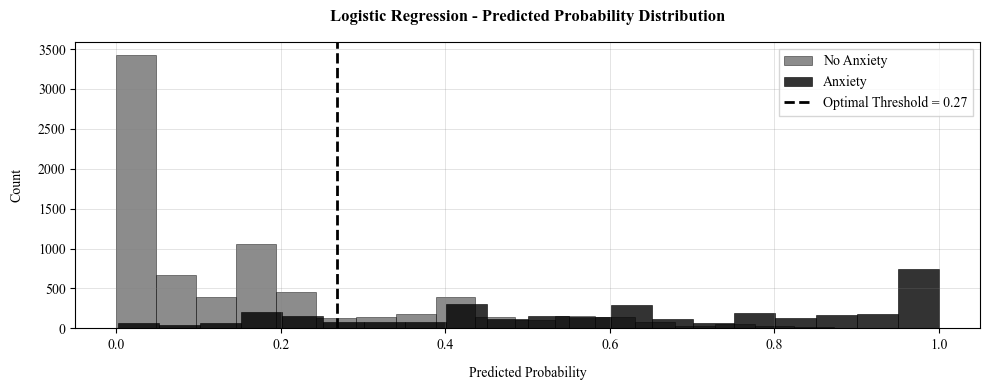

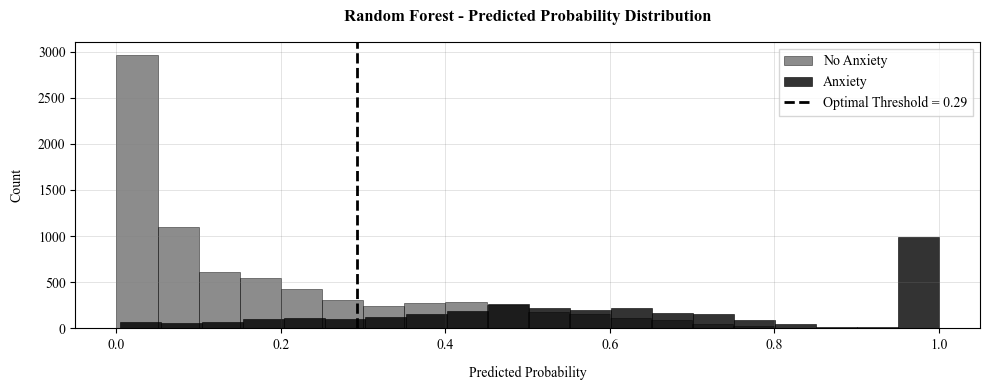

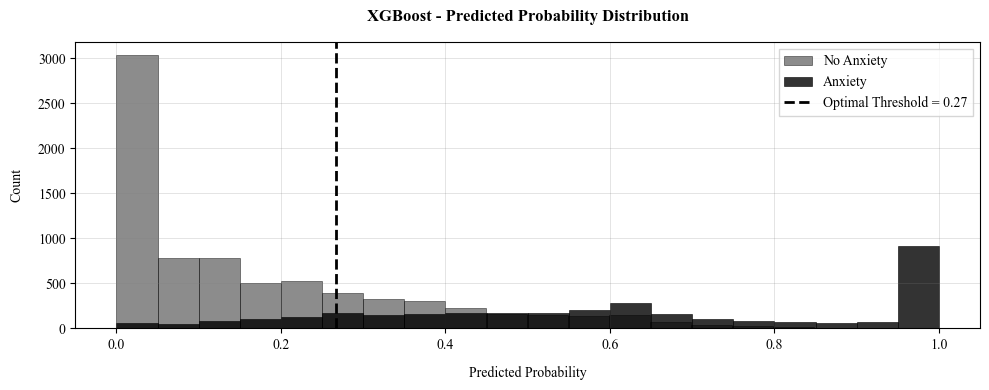


Top 15 features for Logistic Regression:
  Stress Level (1-10): 1.8771 (increases risk)
  Sleep Hours: -0.7585 (decreases risk)
  Therapy Sessions (per month): 0.5317 (increases risk)
  Caffeine Intake (mg/day): 0.4718 (increases risk)
  Occupation_Student: -0.1799 (decreases risk)
  Occupation_Nurse: 0.1441 (increases risk)
  Occupation_Doctor: 0.1421 (increases risk)
  Occupation_Other: 0.1068 (increases risk)
  Medication: 0.0897 (increases risk)
  Recent Major Life Event: 0.0809 (increases risk)
  Occupation_Lawyer: 0.0808 (increases risk)
  Occupation_Athlete: -0.0805 (decreases risk)
  Alcohol Consumption (drinks/week): 0.0738 (increases risk)
  Gender_Other: 0.0733 (increases risk)
  Age: -0.0731 (decreases risk)


/tmp/ipykernel_2665/3204130913.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=10, frameon=True, fancybox=False, loc='best')


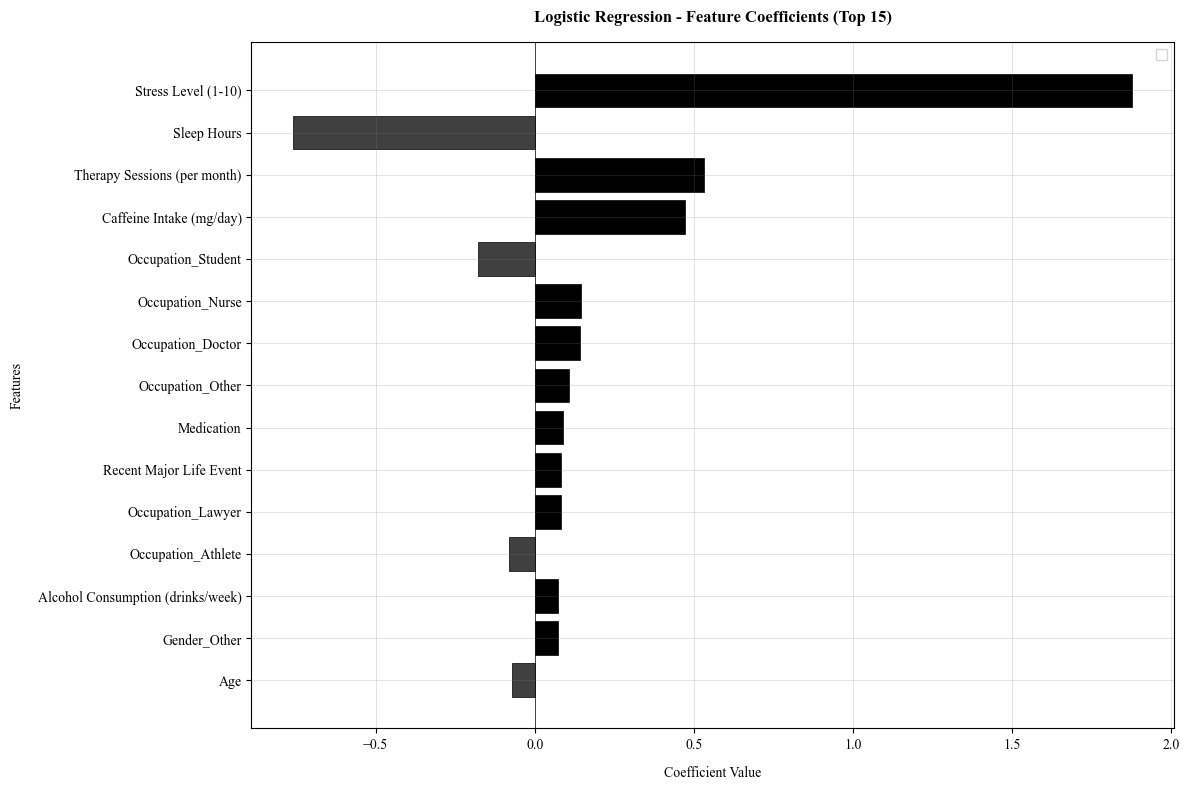


Top 15 features for Random Forest:
  Stress Level (1-10): 0.3114
  Sleep Hours: 0.1086
  Caffeine Intake (mg/day): 0.0850
  Physical Activity (hrs/week): 0.0589
  Therapy Sessions (per month): 0.0552
  Heart Rate (bpm): 0.0536
  Age: 0.0509
  Breathing Rate (breaths/min): 0.0438
  Alcohol Consumption (drinks/week): 0.0428
  Diet Quality (1-10): 0.0404
  Sweating Level (1-5): 0.0271
  Recent Major Life Event: 0.0100
  Medication: 0.0096
  Dizziness: 0.0095
  Gender_Other: 0.0089


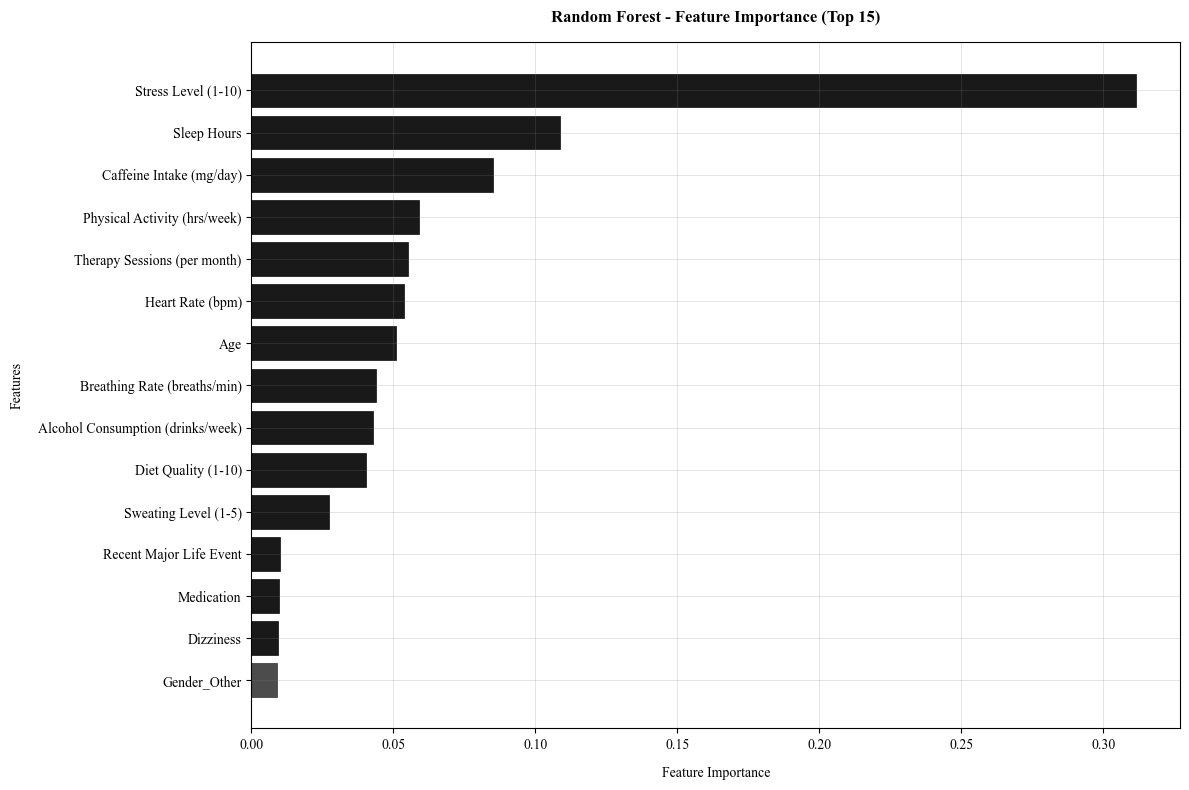


Top 15 features for XGBoost:
  Stress Level (1-10): 0.4402
  Sleep Hours: 0.0664
  Therapy Sessions (per month): 0.0482
  Caffeine Intake (mg/day): 0.0319
  Gender_Male: 0.0246
  Occupation_Athlete: 0.0218
  Occupation_Chef: 0.0201
  Occupation_Scientist: 0.0191
  Sweating Level (1-5): 0.0180
  Alcohol Consumption (drinks/week): 0.0176
  Occupation_Musician: 0.0176
  Diet Quality (1-10): 0.0166
  Occupation_Lawyer: 0.0164
  Age: 0.0162
  Physical Activity (hrs/week): 0.0162


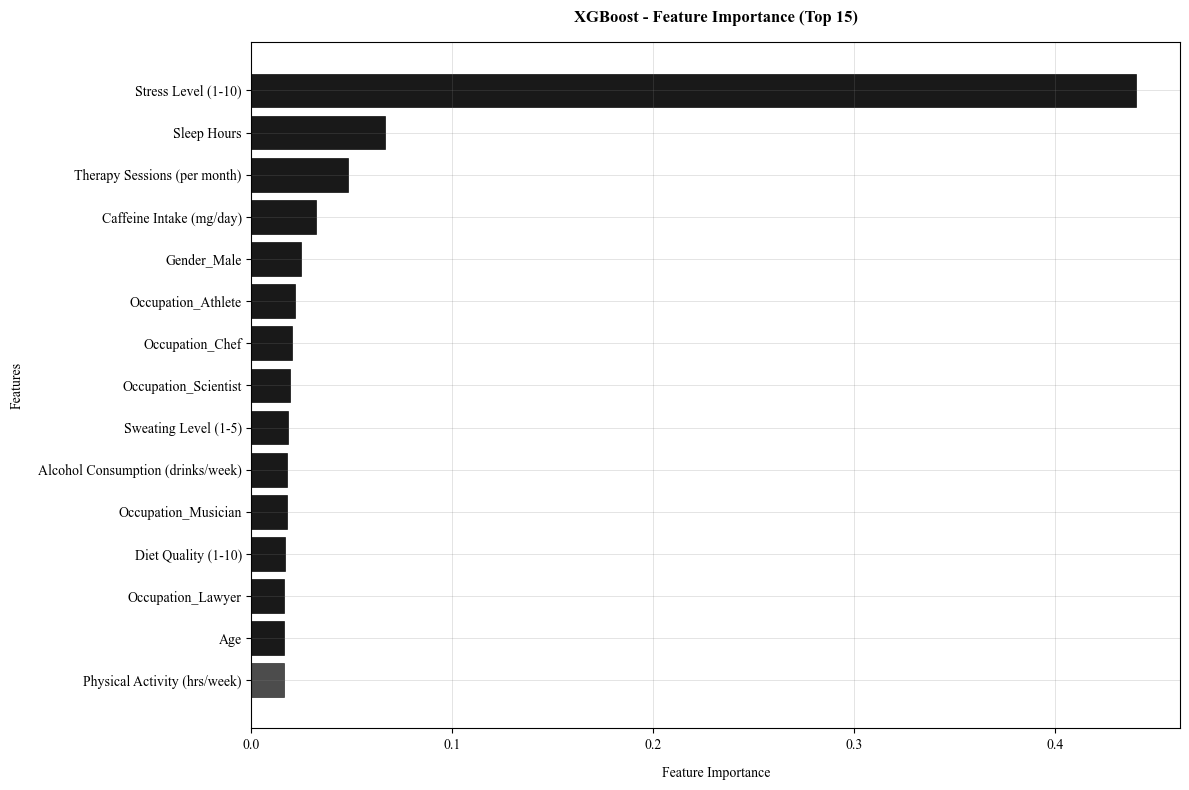

Logistic Regression METRICS (threshold=0.268)
Confusion Matrix:
  True Negatives: 6044
  False Positives: 1574
  False Negatives: 547
  True Positives: 2835

Key Performance Metrics:
  • SENSITIVITY (Recall/True Positive Rate): 0.8383 (83.83%)
  • SPECIFICITY (True Negative Rate): 0.7934 (79.34%)
  • F1-SCORE: 0.7278

Additional Metrics:
  Accuracy: 0.8072 (80.72%)
  Precision: 0.6430 (64.30%)
  ROC AUC: 0.9047
  Brier Score: 0.1114

Classification Report:
              precision    recall  f1-score   support

           0     0.9170    0.7934    0.8507      7618
           1     0.6430    0.8383    0.7278      3382

    accuracy                         0.8072     11000
   macro avg     0.7800    0.8158    0.7892     11000
weighted avg     0.8328    0.8072    0.8129     11000

Random Forest METRICS (threshold=0.293)
Confusion Matrix:
  True Negatives: 5923
  False Positives: 1695
  False Negatives: 510
  True Positives: 2872

Key Performance Metrics:
  • SENSITIVITY (Recall/True Positi

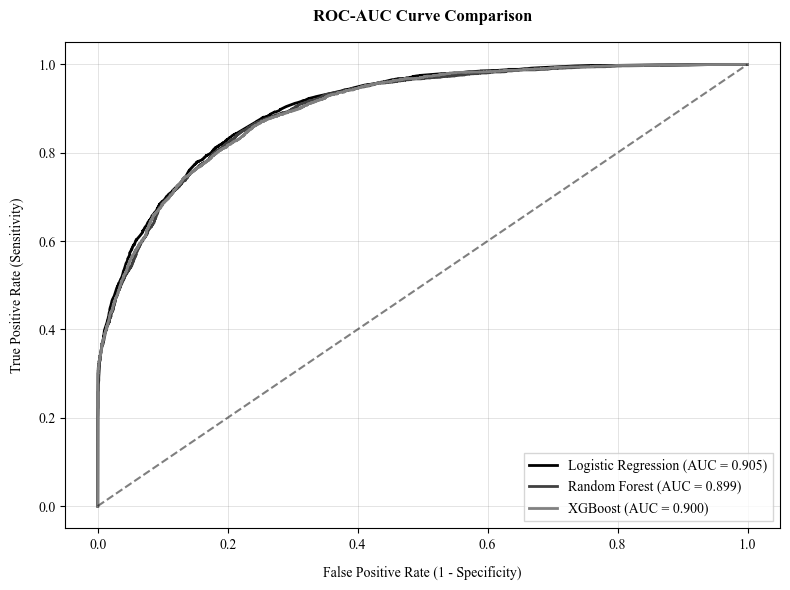

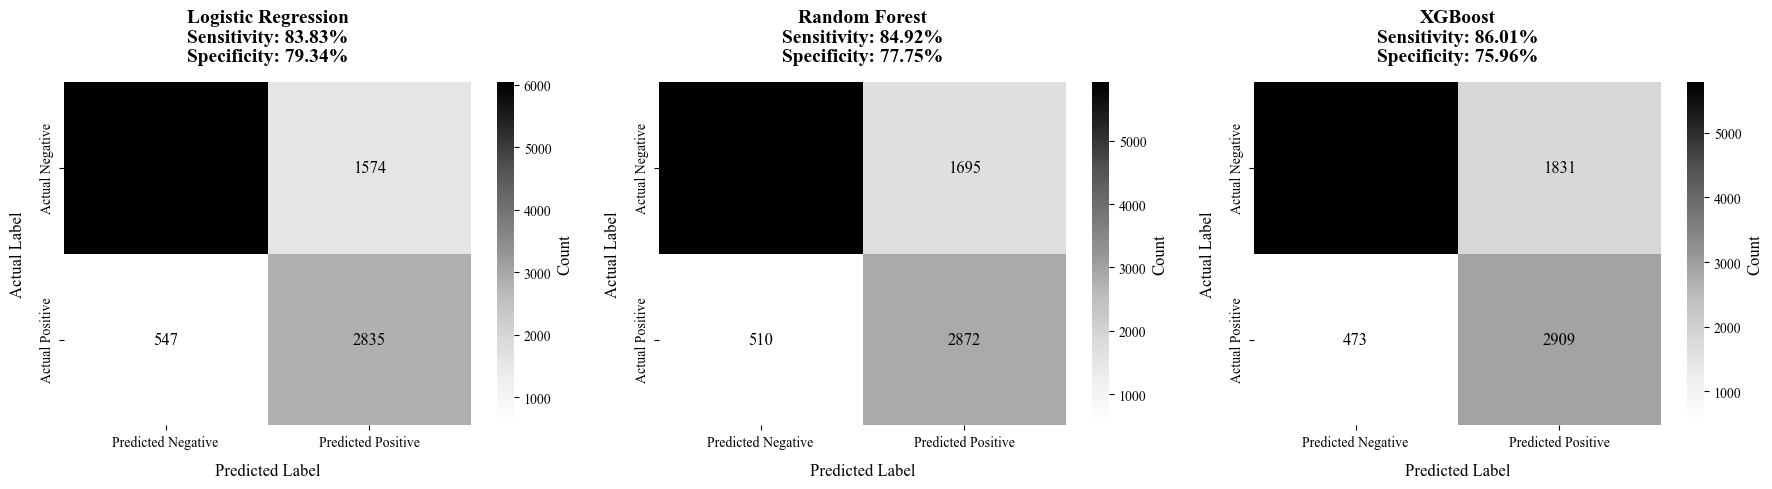

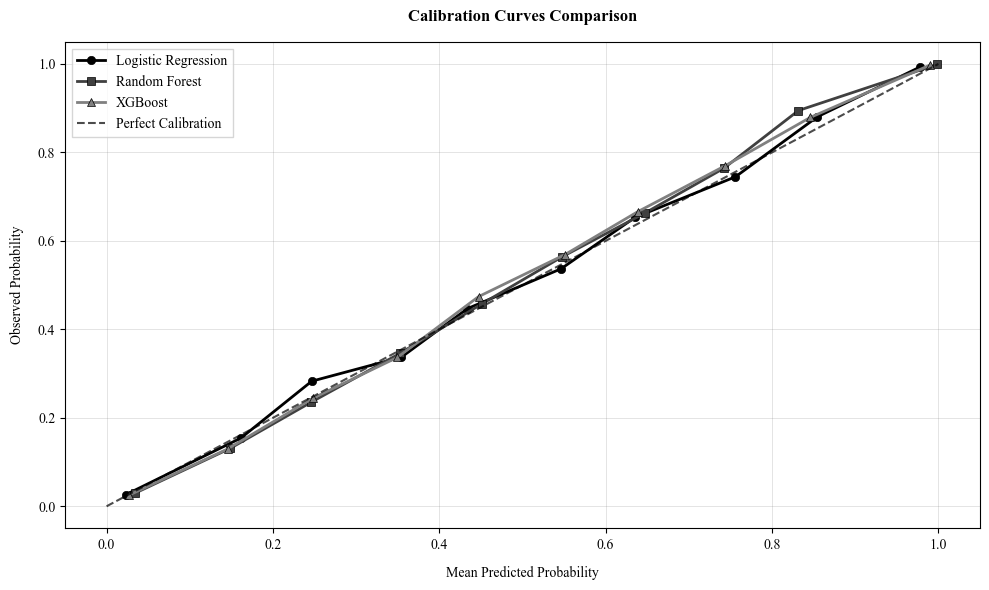


Generating Grayscale SHAP Waterfall Plots for First 3 Patients...


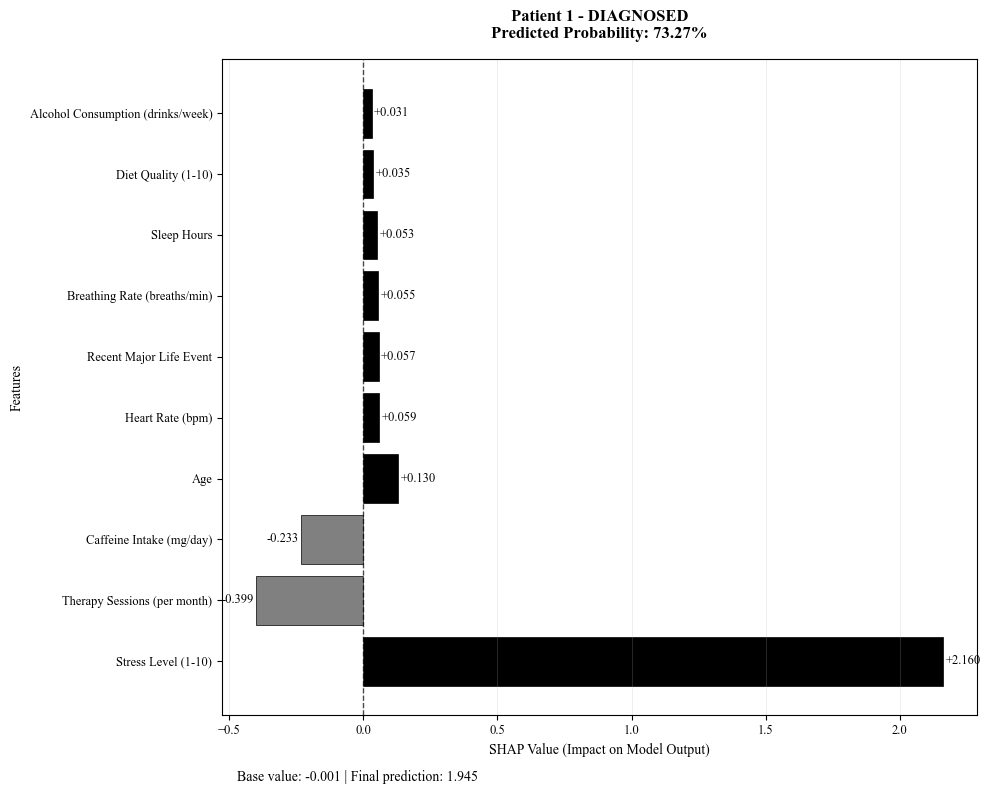

--------------------------------------------------------------------------------


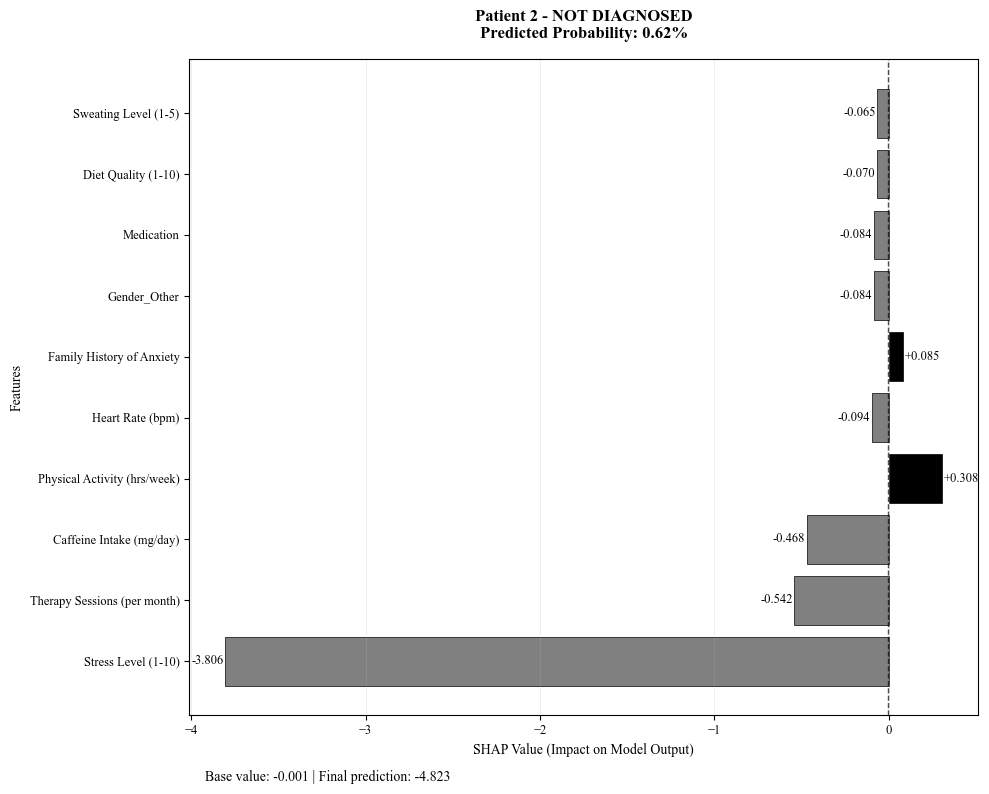

--------------------------------------------------------------------------------


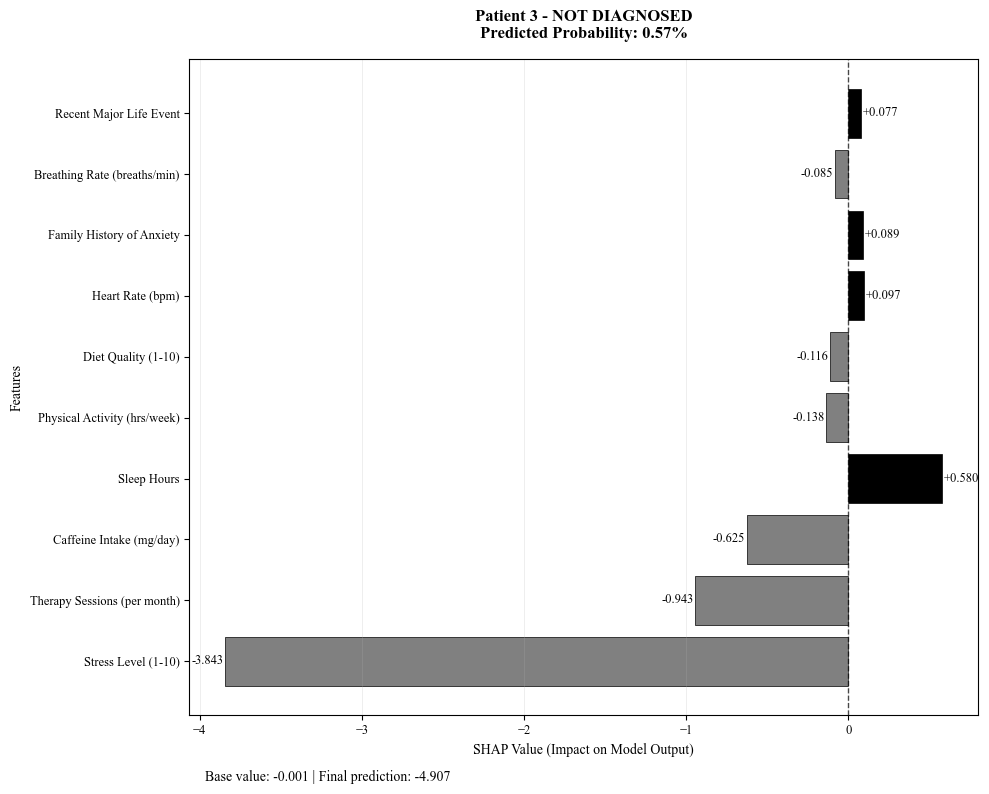

--------------------------------------------------------------------------------
RESULTS TABLE
FIRST 10 PATIENTS
Patient: 1     | Diagnosis: Diagnosed     | Prob: 73.27 % | Risk: High Risk   
  ↑ Increasing: Stress Level (1-10) (+2.160), Age (+0.130), Heart Rate (bpm) (+0.059), Recent Major Life Event (+0.057), Breathing Rate (breaths/min) (+0.055)
  ↓ Decreasing: Therapy Sessions (per month) (-0.399), Caffeine Intake (mg/day) (-0.233), Gender_Other (-0.022), Dizziness (-0.014), Smoking (-0.007)
--------------------------------------------------------------------------------------------------------------
Patient: 2     | Diagnosis: Not Diagnosed | Prob: 0.62  % | Risk: Low Risk    
  ↑ Increasing: Physical Activity (hrs/week) (+0.308), Family History of Anxiety (+0.085), Sleep Hours (+0.047), Occupation_Nurse (+0.039), Occupation_Student (+0.018)
  ↓ Decreasing: Stress Level (1-10) (-3.806), Therapy Sessions (per month) (-0.542), Caffeine Intake (mg/day) (-0.468), Heart Rate (bpm) (-0.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap
from sklearn.utils import shuffle
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    roc_auc_score, accuracy_score, roc_curve, brier_score_loss,
    precision_score, recall_score, f1_score, confusion_matrix, classification_report
)

# Global font settings
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['figure.titlesize'] = 12

# Default color cycle to grayscale
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=['black', '#404040', '#808080', '#A0A0A0', '#C0C0C0'])

# Styling function for all plots
def style_plot(ax, title, xlabel, ylabel, legend=True, grid=True):
    """Apply consistent styling to plots"""
    ax.set_title(title, fontsize=12, fontweight='bold', pad=15, color='black')
    ax.set_xlabel(xlabel, fontsize=10, labelpad=10, color='black')
    ax.set_ylabel(ylabel, fontsize=10, labelpad=10, color='black')
    if grid:
        ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5, color='gray')
    if legend:
        ax.legend(fontsize=10, frameon=True, fancybox=False, loc='best')
    ax.tick_params(axis='both', which='major', labelsize=10, colors='black')
    # Set spine colors to black
    for spine in ax.spines.values():
        spine.set_color('black')
    return ax

# Load and prepare training data
train_data = pd.read_csv("training_dataset.csv")
X_train = train_data.drop(columns=["Diagnosed", "Anxiety Level (1-10)"])
y_train = train_data["Diagnosed"]
X_train, y_train = shuffle(X_train, y_train, random_state=42)

# Load and prepare test data
test_data = pd.read_csv("testing_dataset.csv")
X_test = test_data.drop(columns=["Diagnosed", "Anxiety Level (1-10)"])
y_test = test_data["Diagnosed"]

# Identifying feature types
numeric_features = X_train.select_dtypes(include=[float, int]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

# Preprocessing pipeline
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(drop="first", sparse_output=False), categorical_features)
])

# Model pipelines
logreg_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced", solver="saga", l1_ratio=0.5, C=1.0))
])

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42))
])

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.1,
                                 eval_metric="logloss", scale_pos_weight=scale_pos_weight, random_state=42))
])

# Calibrated models
logreg_model = CalibratedClassifierCV(logreg_pipeline, method="isotonic", cv=5)
rf_model = CalibratedClassifierCV(rf_pipeline, method="isotonic", cv=5)
xgb_model = CalibratedClassifierCV(xgb_pipeline, method="isotonic", cv=5)

# Model training
logreg_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)

# Get predicted probabilities
logreg_prob = logreg_model.predict_proba(X_test)[:, 1]
rf_prob = rf_model.predict_proba(X_test)[:, 1]
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

# Show first 20 predictions
print("\nPredicted percentages (first 20 patients):")
df_probs = pd.DataFrame({
    "Patient": range(1, 21),
    "Diagnosis(1-Anxiety, 0-No Anxiety)": y_test.iloc[:20].values,
    "Logistic Regression (%)": np.round(logreg_prob[:20]*100, 2),
    "Random Forest (%)": np.round(rf_prob[:20]*100, 2),
    "XGBoost (%)": np.round(xgb_prob[:20]*100, 2)
})
print(df_probs.to_string(index=False))

# Find optimal thresholds
def find_best_threshold(y_true, y_prob):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    best_idx = np.argmax(tpr - fpr)
    return thresholds[best_idx]

logreg_threshold = find_best_threshold(y_test, logreg_prob)
rf_threshold = find_best_threshold(y_test, rf_prob)
xgb_threshold = find_best_threshold(y_test, xgb_prob)

# Plot probability distributions with consistent styling (simple graph - black only)
def plot_probabilities_horizontal(y_true, y_prob, threshold, name):
    df = pd.DataFrame({"Probability": y_prob, "Diagnosis": y_true})
    fig, ax = plt.subplots(figsize=(10, 4))
    # Use different grayscale shades for distinction
    colors = ['#404040', 'black']  # Dark gray for no anxiety, black for anxiety
    for i, diagnosis in enumerate([0, 1]):
        data = df[df["Diagnosis"] == diagnosis]
        label = "No Anxiety" if diagnosis == 0 else "Anxiety"
        alpha = 0.6 if diagnosis == 0 else 0.8
        ax.hist(data["Probability"], bins=20, alpha=alpha, color=colors[i], 
                label=label, edgecolor='black', linewidth=0.5)
    ax.axvline(threshold, color="black", linestyle="--", linewidth=2, 
               label=f"Optimal Threshold = {threshold:.2f}")
    ax = style_plot(ax, f"{name} - Predicted Probability Distribution", 
                   "Predicted Probability", "Count")
    plt.tight_layout()
    plt.show()

plot_probabilities_horizontal(y_test, logreg_prob, logreg_threshold, "Logistic Regression")
plot_probabilities_horizontal(y_test, rf_prob, rf_threshold, "Random Forest")
plot_probabilities_horizontal(y_test, xgb_prob, xgb_threshold, "XGBoost")

# feature importance function with consistent styling
def plot_feature_importance(pipeline_model, name):
    
    classifier = pipeline_model.named_steps["classifier"]

    preprocessor_temp = ColumnTransformer([
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(drop="first", sparse_output=False), categorical_features)
    ])
    preprocessor_temp.fit(X_train)

    numeric_feature_names = numeric_features
    cat_feature_names = preprocessor_temp.named_transformers_["cat"].get_feature_names_out(categorical_features)
    feature_names = list(numeric_feature_names) + list(cat_feature_names)

    fig, ax = plt.subplots(figsize=(12, 8))

    if hasattr(classifier, "feature_importances_"):
        importances = classifier.feature_importances_
        indices = np.argsort(importances)[-15:]
        # Use grayscale bars with varying darkness
        bars = ax.barh(range(len(indices)), importances[indices], color='black', 
                       edgecolor='black', linewidth=0.5, alpha=0.9)
        # Make the top feature slightly lighter for distinction
        bars[0].set_alpha(0.7)
        ax.set_yticks(range(len(indices)))
        ax.set_yticklabels([feature_names[i] for i in indices])
        ax = style_plot(ax, f"{name} - Feature Importance (Top 15)", 
                       "Feature Importance", "Features", legend=False)
        print(f"\nTop 15 features for {name}:")
        for idx in reversed(indices):
            print(f"  {feature_names[idx]}: {importances[idx]:.4f}")

    elif hasattr(classifier, "coef_"):
        coefficients = classifier.coef_[0]
        abs_coef = np.abs(coefficients)
        indices = np.argsort(abs_coef)[-15:]
        # Use grayscale: black for positive, dark gray for negative
        colors = ['black' if c > 0 else '#404040' for c in coefficients[indices]]
        ax.barh(range(len(indices)), coefficients[indices], color=colors, 
                edgecolor='black', linewidth=0.5)
        ax.set_yticks(range(len(indices)))
        ax.set_yticklabels([feature_names[i] for i in indices])
        from matplotlib.patches import Patch
        legend_elements = [Patch(facecolor='black', edgecolor='black', label='Positive (increases risk)'),
                          Patch(facecolor='#404040', edgecolor='black', label='Negative (decreases risk)')]
        ax.legend(handles=legend_elements, loc='lower right', fontsize=10, 
                 frameon=True, fancybox=True, shadow=True)
        ax = style_plot(ax, f"{name} - Feature Coefficients (Top 15)", 
                       "Coefficient Value", "Features", legend=True)
        print(f"\nTop 15 features for {name}:")
        for idx in reversed(indices):
            direction = "increases risk" if coefficients[idx] > 0 else "decreases risk"
            print(f"  {feature_names[idx]}: {coefficients[idx]:.4f} ({direction})")

    ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    plt.tight_layout()
    plt.show()


logreg_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)
xgb_pipeline.fit(X_train, y_train)

# Plot feature importance for all models
plot_feature_importance(logreg_pipeline, "Logistic Regression")
plot_feature_importance(rf_pipeline, "Random Forest")
plot_feature_importance(xgb_pipeline, "XGBoost")

# evaluation model
def evaluate_model(y_true, y_prob, threshold, name):
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_prob)
    brier = brier_score_loss(y_true, y_prob)
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

   
    print(f"{name} METRICS (threshold={threshold:.3f})")
    print(f"Confusion Matrix:")
    print(f"  True Negatives: {tn}")
    print(f"  False Positives: {fp}")
    print(f"  False Negatives: {fn}")
    print(f"  True Positives: {tp}")
    print(f"\nKey Performance Metrics:")
    print(f"  • SENSITIVITY (Recall/True Positive Rate): {sensitivity:.4f} ({sensitivity*100:.2f}%)")
    print(f"  • SPECIFICITY (True Negative Rate): {specificity:.4f} ({specificity*100:.2f}%)")
    print(f"  • F1-SCORE: {f1:.4f}")
    print(f"\nAdditional Metrics:")
    print(f"  Accuracy: {acc:.4f} ({acc*100:.2f}%)")
    print(f"  Precision: {prec:.4f} ({prec*100:.2f}%)")
    print(f"  ROC AUC: {roc_auc:.4f}")
    print(f"  Brier Score: {brier:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_true, y_pred, digits=4))

    return confusion_matrix(y_true, y_pred), {
        'sensitivity': sensitivity,
        'specificity': specificity,
        'f1_score': f1,
        'precision': prec,
        'accuracy': acc,
        'roc_auc': roc_auc
    }

# Evaluate models
logreg_cm, logreg_metrics = evaluate_model(y_test, logreg_prob, logreg_threshold, "Logistic Regression")
rf_cm, rf_metrics = evaluate_model(y_test, rf_prob, rf_threshold, "Random Forest")
xgb_cm, xgb_metrics = evaluate_model(y_test, xgb_prob, xgb_threshold, "XGBoost")

# Model comparison table
comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Threshold': [logreg_threshold, rf_threshold, xgb_threshold],
    'Sensitivity (%)': [logreg_metrics['sensitivity']*100, rf_metrics['sensitivity']*100, xgb_metrics['sensitivity']*100],
    'Specificity (%)': [logreg_metrics['specificity']*100, rf_metrics['specificity']*100, xgb_metrics['specificity']*100],
    'F1-Score': [logreg_metrics['f1_score'], rf_metrics['f1_score'], xgb_metrics['f1_score']],
    'Precision (%)': [logreg_metrics['precision']*100, rf_metrics['precision']*100, xgb_metrics['precision']*100],
    'Accuracy (%)': [logreg_metrics['accuracy']*100, rf_metrics['accuracy']*100, xgb_metrics['accuracy']*100],
    'ROC-AUC': [logreg_metrics['roc_auc'], rf_metrics['roc_auc'], xgb_metrics['roc_auc']]
}).round(2)

print("\nMODEL COMPARISON SUMMARY\n", comparison_df.to_string(index=False))

# ROC curve with consistent styling (combined graph - black and gray)
fig, ax = plt.subplots(figsize=(8, 6))
# Use grayscale colors for different models
colors = ['black', '#404040', '#808080']  
for prob, label, color in zip([logreg_prob, rf_prob, xgb_prob], 
                              ["Logistic Regression", "Random Forest", "XGBoost"],
                              colors):
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    ax.plot(fpr, tpr, color=color, linewidth=2, linestyle='-', label=f"{label} (AUC = {auc:.3f})")
ax.plot([0,1], [0,1], color='black', linestyle='--', linewidth=1.5, alpha=0.5)
ax = style_plot(ax, "ROC-AUC Curve Comparison", 
               "False Positive Rate (1 - Specificity)", 
               "True Positive Rate (Sensitivity)")
plt.tight_layout()
plt.show()

# Confusion matrices with consistent styling (grayscale colormap)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sensitivity_labels = [
    f"Sensitivity: {logreg_metrics['sensitivity']:.2%}\nSpecificity: {logreg_metrics['specificity']:.2%}",
    f"Sensitivity: {rf_metrics['sensitivity']:.2%}\nSpecificity: {rf_metrics['specificity']:.2%}",
    f"Sensitivity: {xgb_metrics['sensitivity']:.2%}\nSpecificity: {xgb_metrics['specificity']:.2%}"
]

model_names = ['Logistic Regression', 'Random Forest', 'XGBoost']
for idx, (cm, ax, label, name) in enumerate(zip([logreg_cm, rf_cm, xgb_cm], axes, sensitivity_labels, model_names)):
    # Use grayscale colormap for confusion matrices
    sns.heatmap(cm, annot=True, fmt="d", cmap="Greys", ax=ax, 
                xticklabels=['Predicted Negative', 'Predicted Positive'],
                yticklabels=['Actual Negative', 'Actual Positive'],
                annot_kws={'size': 12, 'color': 'black'}, 
                cbar_kws={'label': 'Count'})
    ax.set_xlabel("Predicted Label", fontsize=12, labelpad=10, color='black')
    ax.set_ylabel("Actual Label", fontsize=12, labelpad=10, color='black')
    ax.set_title(f"{name}\n{label}", fontsize=14, fontweight='bold', pad=15, color='black')
    ax.tick_params(axis='both', which='major', labelsize=10, colors='black')
    # Adjust colorbar to be grayscale
    cbar = ax.collections[0].colorbar
    cbar.set_label('Count', color='black')
    cbar.ax.yaxis.set_tick_params(color='black')
    plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='black')
plt.tight_layout()
plt.show()

# Calibration curve with consistent styling (combined graph - black and gray)
fig, ax = plt.subplots(figsize=(10, 6))
# Use grayscale colors and markers
colors = ['black', '#404040', '#808080']
markers = ['o', 's', '^']
for prob, label, color, marker in zip([logreg_prob, rf_prob, xgb_prob], 
                                       ["Logistic Regression", "Random Forest", "XGBoost"],
                                       colors, markers):
    prob_true, prob_pred = calibration_curve(y_test, prob, n_bins=10)
    ax.plot(prob_pred, prob_true, marker=marker, markersize=6, linewidth=2, 
            color=color, label=label, markeredgecolor='black', markeredgewidth=0.5)
ax.plot([0,1], [0,1], linestyle='--', color='black', linewidth=1.5, alpha=0.7, 
        label='Perfect Calibration')
ax = style_plot(ax, "Calibration Curves Comparison", 
               "Mean Predicted Probability", 
               "Observed Probability")
plt.tight_layout()
plt.show()

# Get feature names after preprocessing
preprocessor_temp = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(drop="first", sparse_output=False), categorical_features)
])
preprocessor_temp.fit(X_train)

numeric_feature_names = numeric_features
cat_feature_names = preprocessor_temp.named_transformers_["cat"].get_feature_names_out(categorical_features)
feature_names = list(numeric_feature_names) + list(cat_feature_names)

# Transform the data
X_train_transformed = preprocessor_temp.transform(X_train)
X_test_transformed = preprocessor_temp.transform(X_test)

# Get the underlying XGBoost model (not the calibrated one)
xgb_model_uncalibrated = xgb_pipeline.named_steps['classifier']

# Create SHAP explainer
explainer = shap.TreeExplainer(xgb_model_uncalibrated)

# Calculate SHAP values for test set
shap_values = explainer.shap_values(X_test_transformed)

# Custom function to create grayscale waterfall plots
def plot_grayscale_waterfall(shap_values, expected_value, features, feature_names, max_display=12, title=None):
    """Create a waterfall plot in grayscale using simplified custom visualization"""
    
    # Sort features by absolute SHAP value
    feature_impacts = list(zip(feature_names, shap_values))
    feature_impacts.sort(key=lambda x: abs(x[1]), reverse=True)
    
    # Take top features
    top_features = feature_impacts[:max_display]
    
    # Calculate cumulative effect
    cumulative = expected_value
    cumulative_values = [cumulative]
    
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Plot bars for each feature
    y_positions = range(len(top_features))
    bar_colors = []
    bar_values = []
    
    for i, (name, impact) in enumerate(top_features):
        if impact > 0:
            bar_colors.append('black')  # Positive impact - black
        else:
            bar_colors.append('#808080')  # Negative impact - gray
        
        bar_values.append(impact)
    
    # Create horizontal bars
    bars = ax.barh(y_positions, bar_values, color=bar_colors, edgecolor='black', linewidth=0.5)
    
    # Add text labels for values
    for i, (name, impact) in enumerate(top_features):
        if impact > 0:
            ax.text(impact + 0.01, i, f'+{impact:.3f}', va='center', fontsize=9, color='black')
        else:
            ax.text(impact - 0.01, i, f'{impact:.3f}', va='center', ha='right', fontsize=9, color='black')
    
    # Set y-ticks with feature names
    ax.set_yticks(y_positions)
    ax.set_yticklabels([name for name, _ in top_features])
    
    # Add baseline value
    ax.axvline(x=expected_value, color='black', linestyle='--', linewidth=1, alpha=0.7)
    
    # Calculate final prediction
    final_prediction = expected_value + sum(bar_values)
    
    # Add title with information
    ax.set_title(title, fontsize=12, fontweight='bold', pad=15, color='black')
    ax.set_xlabel('SHAP Value (Impact on Model Output)', fontsize=10, color='black')
    ax.set_ylabel('Features', fontsize=10, color='black')
    
    # Add text for final prediction
    ax.text(0.02, -0.1, f'Base value: {expected_value:.3f} | Final prediction: {final_prediction:.3f}', 
            transform=ax.transAxes, fontsize=10, color='black')
    
    # Add grid
    ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5, axis='x')
    
    # Style the plot
    ax.tick_params(axis='both', which='major', labelsize=9, colors='black')
    for spine in ax.spines.values():
        spine.set_color('black')
    
    plt.tight_layout()
    plt.show()

print("\nGenerating Grayscale SHAP Waterfall Plots for First 3 Patients...")

for i in range(min(3, len(X_test))):
    diagnosis_text = 'DIAGNOSED' if y_test.iloc[i] == 1 else 'NOT DIAGNOSED'
    predicted_prob = xgb_prob[i]
    # Convert log odds to probability for display
    title = f"Patient {i+1} - {diagnosis_text}\nPredicted Probability: {predicted_prob:.2%}"
    
    plot_grayscale_waterfall(
        shap_values[i],
        explainer.expected_value,
        X_test_transformed[i],
        feature_names,
        max_display=10,
        title=title
    )
    print("-" * 80)

print("RESULTS TABLE")

# Function to get top features for a patient based on SHAP values
def get_top_shap_features(shap_values_row, feature_names, n_top=5, positive=True):
    """
    Get top n features with highest positive or negative SHAP values
    """
    if positive:
        # Get indices of top positive SHAP values
        indices = np.argsort(shap_values_row)[-n_top:][::-1]
    else:
        # Get indices of top negative SHAP values (most negative)
        indices = np.argsort(shap_values_row)[:n_top]
    
    features = []
    for idx in indices:
        if positive and shap_values_row[idx] > 0:
            features.append(f"{feature_names[idx]} (+{shap_values_row[idx]:.3f})")
        elif not positive and shap_values_row[idx] < 0:
            features.append(f"{feature_names[idx]} ({shap_values_row[idx]:.3f})")
    
    # Pad with empty strings if less than n_top
    while len(features) < n_top:
        features.append("")
    
    return features

# Create risk categories based on predicted probability
def categorize_risk(prob, low_thresh=0.3, high_thresh=0.7):
    if prob < low_thresh:
        return "Low Risk"
    elif prob < high_thresh:
        return "Moderate Risk"
    else:
        return "High Risk"

xgb_risk_category = [categorize_risk(p) for p in xgb_prob]

# Get top features for each patient
top_increase_features = []
top_decrease_features = []

for i in range(len(xgb_prob)):
    increase_features = get_top_shap_features(shap_values[i], feature_names, n_top=5, positive=True)
    decrease_features = get_top_shap_features(shap_values[i], feature_names, n_top=5, positive=False)
    
    top_increase_features.append(increase_features)
    top_decrease_features.append(decrease_features)

# Create enhanced results table
results_table = pd.DataFrame({
    "Patient": range(1, len(xgb_prob) + 1),
    "Diagnosis(1-Anxiety, 0-No Anxiety)": ["Diagnosed" if val == 1 else "Not Diagnosed" for val in y_test.values],
    "Predicted Prob (%)": np.round(xgb_prob * 100, 2),
    "Risk Category": xgb_risk_category,
    "Top 5 Increasing Risk Factors": [", ".join([f for f in feat if f != ""]) for feat in top_increase_features],
    "Top 5 Decreasing Risk Factors": [", ".join([f for f in feat if f != ""]) for feat in top_decrease_features]
})

# Set pandas display options for left alignment
pd.set_option('display.max_colwidth', 50)
pd.set_option('display.width', 120)
pd.set_option('display.colheader_justify', 'left')

# Display FIRST 10 patients
print("FIRST 10 PATIENTS")
for i in range(min(10, len(results_table))):
    row = results_table.iloc[i]
    print(f"Patient: {row['Patient']:<5} | Diagnosis: {row['Diagnosis(1-Anxiety, 0-No Anxiety)']:<13} | "
          f"Prob: {row['Predicted Prob (%)']:<6}% | Risk: {row['Risk Category']:<12}")
    print(f"  ↑ Increasing: {row['Top 5 Increasing Risk Factors']}")
    print(f"  ↓ Decreasing: {row['Top 5 Decreasing Risk Factors']}")
    print("-" * 110)

# Display LAST 10 patients
print("LAST 10 PATIENTS")
start_idx = max(0, len(results_table) - 10)
for i in range(start_idx, len(results_table)):
    row = results_table.iloc[i]
    print(f"Patient: {row['Patient']:<5} | Diagnosis: {row['Diagnosis(1-Anxiety, 0-No Anxiety)']:<13} | "
          f"Prob: {row['Predicted Prob (%)']:<6}% | Risk: {row['Risk Category']:<12}")
    print(f"  ↑ Increasing: {row['Top 5 Increasing Risk Factors']}")
    print(f"  ↓ Decreasing: {row['Top 5 Decreasing Risk Factors']}")
    print("-" * 110)

# Save full results table to CSV
results_table.to_csv("predictions_with_explanation.csv", index=False)
print("\nFull results table saved to 'predictions_with_explanation.csv'")

# Create summary statistics for risk categories
print("RISK CATEGORY DISTRIBUTION")
risk_summary = results_table.groupby('Risk Category').agg({
    'Patient': 'count',
}).rename(columns={'Patient': 'Count'})
risk_summary['Percentage'] = (risk_summary['Count'] / len(results_table) * 100).round(2)
print(risk_summary.to_string())

# Save model
joblib.dump(xgb_model, 'predictive_model.pkl', compress=3)
print("\nModel saved as predictive_model.pkl")